# Grid 4×4 — Homo, Hetero & Slow-start

Corrected `sumo4x4`, seed 42. **RL**: 200 episodes (`*DTL.log`, test ATT). **Baselines**: single 3600-step eval (`*BRF.log` Final Travel Time). Each row is tied to a specific log path — toggles are never mixed.


In [54]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

REPO = Path('..').resolve()
OUT = REPO / 'data' / 'output_data' / 'tsc'
COLS = ['model', 'split', 'episode', 'travel_time', 'col5', 'reward', 'queue', 'delay', 'throughput']

# --- RL runs (200 ep) — one logger dir per toggle × method ---
EXPERIMENTS = {
    'homo': {
        'toggle': 'homo (default vType)',
        'rl': {
            'DQN': OUT / 'sumo_dqn_sumo4x4' / 'sumo4x4' / 'homo_4x4' / 'logger',
            'PressLight': OUT / 'sumo_presslight_sumo4x4' / 'sumo4x4' / 'homo_4x4' / 'logger',
            'CoLight': OUT / 'sumo_colight' / 'sumo4x4' / 'homo_4x4' / 'logger',
        },
        'baselines': {
            # gpujobs 2026-07-11 — logs not committed; values verified from terminal output
            'MaxPressure': {'att': 172.7235, 'log': 'gpujobs baseline_homo (BRF not in repo)'},
            'FixedTime': {'att': 217.7712, 'log': 'gpujobs baseline_homo (BRF not in repo)'},
        },
    },
    'hetero': {
        'toggle': 'hetero (80% car / 20% truck)',
        'rl': {
            'DQN': OUT / 'sumo_dqn_hetero_sumo4x4' / 'sumo4x4' / 'hetero_4x4' / 'logger',
            'PressLight': OUT / 'sumo_presslight_hetero_sumo4x4' / 'sumo4x4' / 'hetero_4x4' / 'logger',
            'CoLight': OUT / 'sumo_colight_hetero' / 'sumo4x4' / 'hetero_4x4' / 'logger',
        },
        'baselines': {
            'MaxPressure': {'att': 189.3287, 'log': 'gpujobs baseline_hetero (BRF not in repo)'},
            'FixedTime': {'att': 240.3799, 'log': 'gpujobs baseline_hetero (BRF not in repo)'},
        },
    },
    'slow_start': {
        'toggle': 'slow_start (accel=1.0, tau=1.9)',
        'rl': {
            'DQN': OUT / 'sumo_dqn_slow_start' / 'sumo4x4' / 'slow_start_4x4' / 'logger',
            'PressLight': OUT / 'sumo_presslight_slow_start' / 'sumo4x4' / 'slow_start_4x4' / 'logger',
            'CoLight': OUT / 'sumo_colight_slow_start' / 'sumo4x4' / 'slow_start_4x4' / 'logger',
        },
        'baselines': {
            'MaxPressure': OUT / 'sumo_maxpressure_slow_start' / 'sumo4x4' / 'baseline_slow_start' / 'logger',
            'FixedTime': OUT / 'sumo_fixedtime_slow_start' / 'sumo4x4' / 'baseline_slow_start' / 'logger',
        },
    },
}

def load_dtl(logger_dir: Path):
    """Pick the DTL log with the highest episode index (complete 200-ep run)."""
    best, best_ep, best_path = None, -1, None
    for p in sorted(logger_dir.glob('*_DTL.log')):
        df = pd.read_csv(p, sep='\t', header=None, names=COLS)
        mx = int(df['episode'].max())
        if mx > best_ep:
            best, best_ep, best_path = df, mx, p
    if best is None:
        raise FileNotFoundError(f'No DTL logs in {logger_dir}')
    return best, best_path

def parse_brf_att(path: Path) -> float:
    text = path.read_text()
    m = re.search(r'Final Travel Time is ([0-9.]+)', text)
    if not m:
        raise ValueError(f'No Final Travel Time in {path}')
    return float(m.group(1))

def split_curves(df):
    train = df[df.split == 'TRAIN'].reset_index(drop=True)
    test = df[df.split == 'TEST'].reset_index(drop=True)
    return train, test

def load_baseline(toggle: str, method: str):
    spec = EXPERIMENTS[toggle]['baselines'][method]
    if isinstance(spec, dict) and 'att' in spec:
        return spec['att'], spec['log']
    brf = sorted(spec.glob('*_BRF.log'))[-1]
    return parse_brf_att(brf), str(brf.relative_to(REPO))


In [55]:
# Verify slow-start pull (should show episode 199 + BRF baselines)
for name, d in EXPERIMENTS['slow_start']['rl'].items():
    df, p = load_dtl(d)
    te = df[df.split == 'TEST']
    print(f"{name:12s} ep_max={int(df.episode.max()):3d}  final_test={te.travel_time.iloc[-1]:.1f}s  log={p.name}")
for m in ['MaxPressure', 'FixedTime']:
    att, src = load_baseline('slow_start', m)
    print(f"{m:12s} baseline ATT={att:.1f}s  log={src}")


DQN          ep_max=199  final_test=184.7s  log=2026_07_11-15_03_30_DTL.log
PressLight   ep_max=199  final_test=188.7s  log=2026_07_11-15_03_30_DTL.log
CoLight      ep_max=199  final_test=187.1s  log=2026_07_11-15_03_29_DTL.log
MaxPressure  baseline ATT=186.0s  log=data/output_data/tsc/sumo_maxpressure_slow_start/sumo4x4/baseline_slow_start/logger/2026_07_11-14_53_19_BRF.log
FixedTime    baseline ATT=243.7s  log=data/output_data/tsc/sumo_fixedtime_slow_start/sumo4x4/baseline_slow_start/logger/2026_07_11-14_56_02_BRF.log


## 1. Homo 4×4

In [56]:
homo_rl = {}
for name, path in EXPERIMENTS['homo']['rl'].items():
    df, log_path = load_dtl(path)
    train, test = split_curves(df)
    homo_rl[name] = {'df': df, 'train': train, 'test': test, 'log': log_path}
    print(f"{name:12s} best_test={test.travel_time.min():.1f}s  final={test.travel_time.iloc[-1]:.1f}s  ({log_path.name})")


DQN          best_test=167.8s  final=167.9s  (2026_07_09-17_22_29_DTL.log)
PressLight   best_test=171.9s  final=174.4s  (2026_07_09-17_22_29_DTL.log)
CoLight      best_test=168.9s  final=173.1s  (2026_07_09-17_24_53_DTL.log)


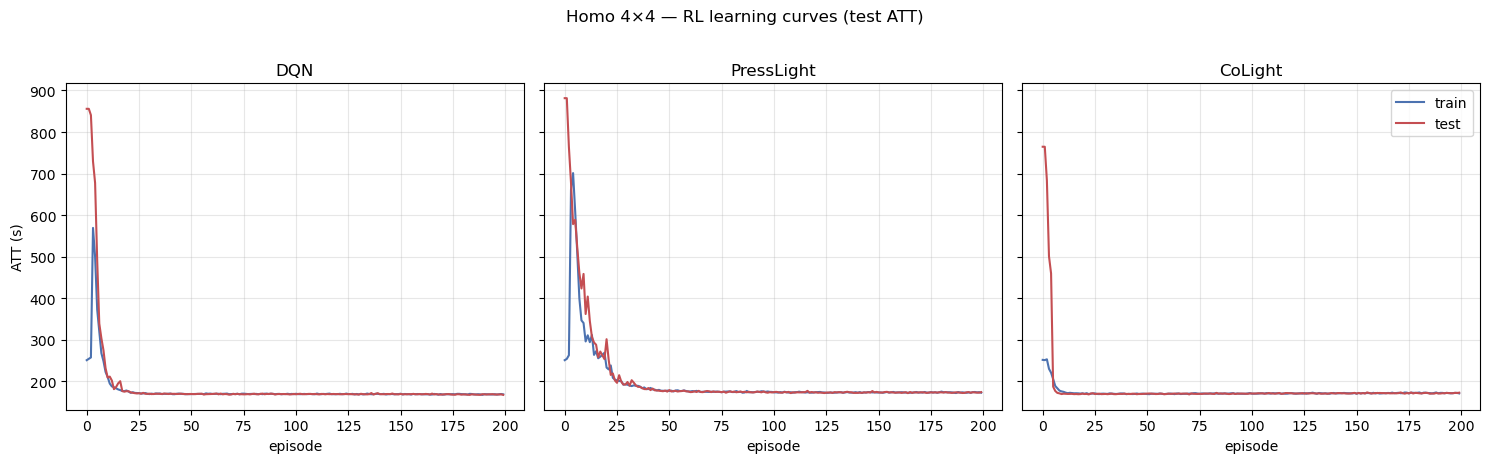

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
colors = {'train': '#4C72B0', 'test': '#C44E52'}
for ax, name in zip(axes, homo_rl):
    tr, te = homo_rl[name]['train'], homo_rl[name]['test']
    ax.plot(tr.index, tr.travel_time, color=colors['train'], label='train')
    ax.plot(te.index, te.travel_time, color=colors['test'], label='test')
    ax.set_title(name)
    ax.set_xlabel('episode')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('ATT (s)')
axes[-1].legend()
fig.suptitle('Homo 4×4 — RL learning curves (test ATT)', y=1.02)
plt.tight_layout()
plt.show()


In [58]:
homo_rows = []
for name in homo_rl:
    te = homo_rl[name]['test']
    homo_rows.append({'method': name, 'best_test_att': round(te.travel_time.min(), 1),
                      'final_test_att': round(te.travel_time.iloc[-1], 1),
                      'log': homo_rl[name]['log'].name})
for m in ['MaxPressure', 'FixedTime']:
    att, src = load_baseline('homo', m)
    homo_rows.append({'method': m, 'best_test_att': round(att, 1), 'final_test_att': round(att, 1), 'log': Path(src).name if '/' in src else src})
homo_table = pd.DataFrame(homo_rows).sort_values('final_test_att')
homo_table


,method,best_test_att,final_test_att,log
0,DQN,167.8,167.9,2026_07_09-17_22_29_DTL.log
3,MaxPressure,172.7,172.7,gpujobs baseline_homo (BRF not in repo)
2,CoLight,168.9,173.1,2026_07_09-17_24_53_DTL.log
1,PressLight,171.9,174.4,2026_07_09-17_22_29_DTL.log
4,FixedTime,217.8,217.8,gpujobs baseline_homo (BRF not in repo)


## 2. Hetero 4×4

In [59]:
hetero_rl = {}
for name, path in EXPERIMENTS['hetero']['rl'].items():
    df, log_path = load_dtl(path)
    train, test = split_curves(df)
    hetero_rl[name] = {'df': df, 'train': train, 'test': test, 'log': log_path}
    print(f"{name:12s} best_test={test.travel_time.min():.1f}s  final={test.travel_time.iloc[-1]:.1f}s  ({log_path.name})")


DQN          best_test=186.3s  final=187.7s  (2026_07_09-14_59_04_DTL.log)
PressLight   best_test=190.6s  final=192.4s  (2026_07_09-14_59_03_DTL.log)
CoLight      best_test=186.5s  final=191.7s  (2026_07_09-14_59_02_DTL.log)


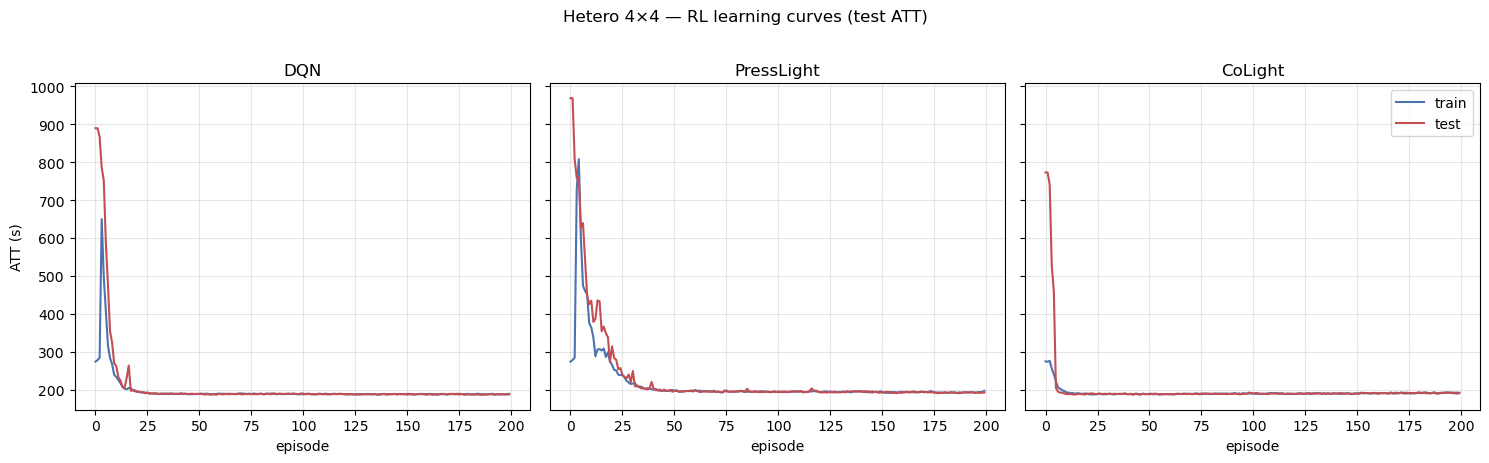

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, name in zip(axes, hetero_rl):
    tr, te = hetero_rl[name]['train'], hetero_rl[name]['test']
    ax.plot(tr.index, tr.travel_time, color=colors['train'], label='train')
    ax.plot(te.index, te.travel_time, color=colors['test'], label='test')
    ax.set_title(name)
    ax.set_xlabel('episode')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('ATT (s)')
axes[-1].legend()
fig.suptitle('Hetero 4×4 — RL learning curves (test ATT)', y=1.02)
plt.tight_layout()
plt.show()


In [61]:
hetero_rows = []
for name in hetero_rl:
    te = hetero_rl[name]['test']
    hetero_rows.append({'method': name, 'best_test_att': round(te.travel_time.min(), 1),
                        'final_test_att': round(te.travel_time.iloc[-1], 1),
                        'log': hetero_rl[name]['log'].name})
for m in ['MaxPressure', 'FixedTime']:
    att, src = load_baseline('hetero', m)
    hetero_rows.append({'method': m, 'best_test_att': round(att, 1), 'final_test_att': round(att, 1), 'log': src})
hetero_table = pd.DataFrame(hetero_rows).sort_values('final_test_att')
hetero_table


,method,best_test_att,final_test_att,log
0,DQN,186.3,187.7,2026_07_09-14_59_04_DTL.log
3,MaxPressure,189.3,189.3,gpujobs baseline_hetero (BRF not in repo)
2,CoLight,186.5,191.7,2026_07_09-14_59_02_DTL.log
1,PressLight,190.6,192.4,2026_07_09-14_59_03_DTL.log
4,FixedTime,240.4,240.4,gpujobs baseline_hetero (BRF not in repo)


## 3. Slow-start 4×4

In [62]:
slow_rl = {}
for name, path in EXPERIMENTS['slow_start']['rl'].items():
    df, log_path = load_dtl(path)
    train, test = split_curves(df)
    slow_rl[name] = {'df': df, 'train': train, 'test': test, 'log': log_path}
    print(f"{name:12s} best_test={test.travel_time.min():.1f}s  final={test.travel_time.iloc[-1]:.1f}s  ({log_path.name})")


DQN          best_test=181.7s  final=184.7s  (2026_07_11-15_03_30_DTL.log)
PressLight   best_test=187.5s  final=188.7s  (2026_07_11-15_03_30_DTL.log)
CoLight      best_test=182.7s  final=187.1s  (2026_07_11-15_03_29_DTL.log)


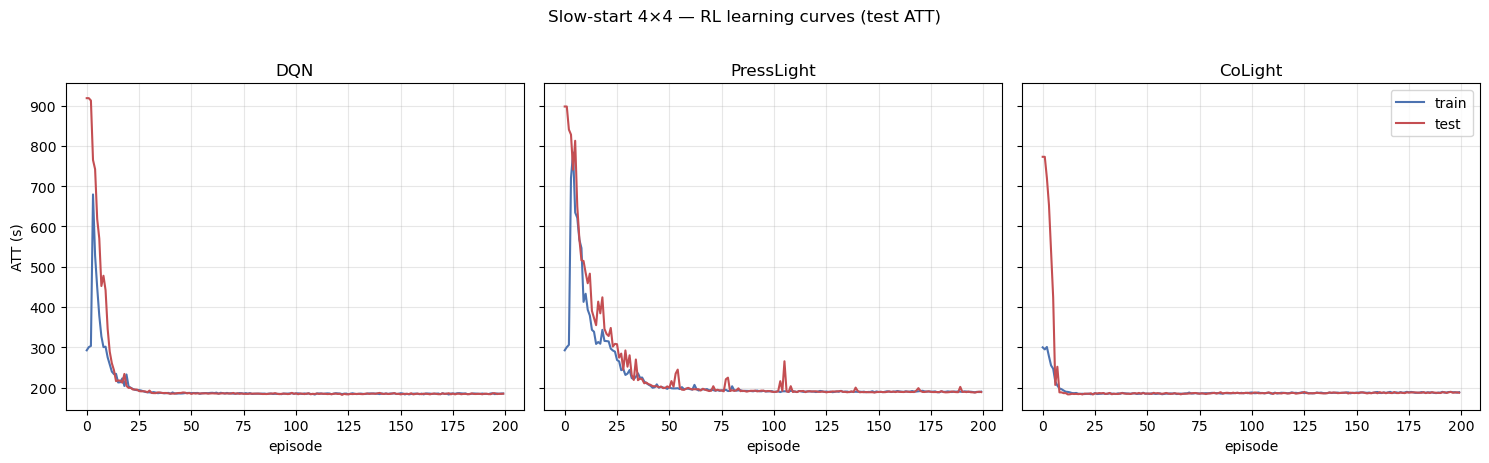

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, name in zip(axes, slow_rl):
    tr, te = slow_rl[name]['train'], slow_rl[name]['test']
    ax.plot(tr.index, tr.travel_time, color=colors['train'], label='train')
    ax.plot(te.index, te.travel_time, color=colors['test'], label='test')
    ax.set_title(name)
    ax.set_xlabel('episode')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('ATT (s)')
axes[-1].legend()
fig.suptitle('Slow-start 4×4 — RL learning curves (test ATT)', y=1.02)
plt.tight_layout()
plt.show()


In [64]:
slow_rows = []
for name in slow_rl:
    te = slow_rl[name]['test']
    slow_rows.append({'method': name, 'best_test_att': round(te.travel_time.min(), 1),
                      'final_test_att': round(te.travel_time.iloc[-1], 1),
                      'log': slow_rl[name]['log'].name})
for m in ['MaxPressure', 'FixedTime']:
    att, src = load_baseline('slow_start', m)
    slow_rows.append({'method': m, 'best_test_att': round(att, 1), 'final_test_att': round(att, 1), 'log': Path(src).name})
slow_table = pd.DataFrame(slow_rows).sort_values('final_test_att')
slow_table


,method,best_test_att,final_test_att,log
0,DQN,181.7,184.7,2026_07_11-15_03_30_DTL.log
3,MaxPressure,186.0,186.0,2026_07_11-14_53_19_BRF.log
2,CoLight,182.7,187.1,2026_07_11-15_03_29_DTL.log
1,PressLight,187.5,188.7,2026_07_11-15_03_30_DTL.log
4,FixedTime,243.7,243.7,2026_07_11-14_56_02_BRF.log


## 4. Cross-toggle ranking (final test / eval ATT, lower is better)

In [65]:
rank_rows = []
for toggle, cfg in EXPERIMENTS.items():
    if toggle == 'homo':
        data = homo_rl
    elif toggle == 'hetero':
        data = hetero_rl
    else:
        data = slow_rl
    for method in ['DQN', 'PressLight', 'CoLight']:
        te = data[method]['test']
        rank_rows.append({
            'toggle': toggle,
            'method': method,
            'type': 'RL (200 ep)',
            'final_att': round(te.travel_time.iloc[-1], 1),
            'best_att': round(te.travel_time.min(), 1),
            'log': data[method]['log'].name,
        })
    for m in ['MaxPressure', 'FixedTime']:
        att, src = load_baseline(toggle, m)
        rank_rows.append({
            'toggle': toggle,
            'method': m,
            'type': 'baseline (3600 steps)',
            'final_att': round(att, 1),
            'best_att': round(att, 1),
            'log': Path(src).name if not str(src).startswith('gpujobs') else src,
        })

ranking = pd.DataFrame(rank_rows)
ranking = ranking.sort_values(['toggle', 'final_att']).reset_index(drop=True)
ranking['rank_in_toggle'] = ranking.groupby('toggle')['final_att'].rank(method='min').astype(int)
ranking


,toggle,method,type,final_att,best_att,log,rank_in_toggle
0,hetero,DQN,RL (200 ep),187.7,186.3,2026_07_09-14_59_04_DTL.log,1
1,hetero,MaxPressure,baseline (3600 steps),189.3,189.3,gpujobs baseline_hetero (BRF not in repo),2
2,hetero,CoLight,RL (200 ep),191.7,186.5,2026_07_09-14_59_02_DTL.log,3
3,hetero,PressLight,RL (200 ep),192.4,190.6,2026_07_09-14_59_03_DTL.log,4
4,hetero,FixedTime,baseline (3600 steps),240.4,240.4,gpujobs baseline_hetero (BRF not in repo),5
5,homo,DQN,RL (200 ep),167.9,167.8,2026_07_09-17_22_29_DTL.log,1
6,homo,MaxPressure,baseline (3600 steps),172.7,172.7,gpujobs baseline_homo (BRF not in repo),2
7,homo,CoLight,RL (200 ep),173.1,168.9,2026_07_09-17_24_53_DTL.log,3
8,homo,PressLight,RL (200 ep),174.4,171.9,2026_07_09-17_22_29_DTL.log,4
9,homo,FixedTime,baseline (3600 steps),217.8,217.8,gpujobs baseline_homo (BRF not in repo),5


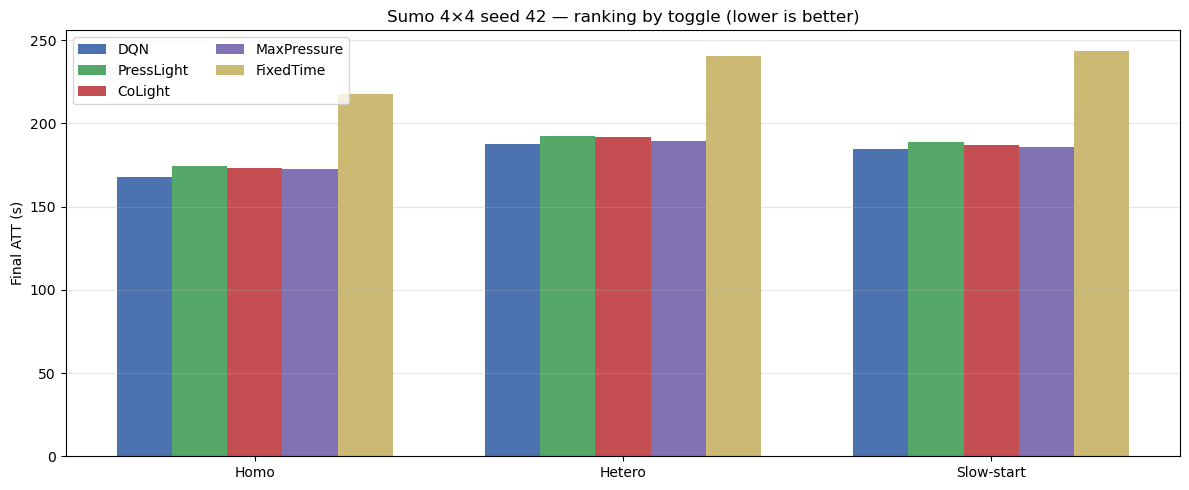

In [66]:
fig, ax = plt.subplots(figsize=(12, 5))
toggle_order = ['homo', 'hetero', 'slow_start']
methods = ['DQN', 'PressLight', 'CoLight', 'MaxPressure', 'FixedTime']
palette = {'DQN': '#4C72B0', 'PressLight': '#55A868', 'CoLight': '#C44E52',
           'MaxPressure': '#8172B3', 'FixedTime': '#CCB974'}
x = range(len(toggle_order))
width = 0.15
for i, method in enumerate(methods):
    vals = [ranking[(ranking.toggle == t) & (ranking.method == method)]['final_att'].values[0] for t in toggle_order]
    ax.bar([xi + (i - 2) * width for xi in x], vals, width, label=method, color=palette[method])
ax.set_xticks(list(x))
ax.set_xticklabels(['Homo', 'Hetero', 'Slow-start'])
ax.set_ylabel('Final ATT (s)')
ax.set_title('Sumo 4×4 seed 42 — ranking by toggle (lower is better)')
ax.legend(loc='upper left', ncol=2)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Summary

- **Homo**: RL ≈ MaxPressure (168–174 s); FixedTime worst (~218 s).
- **Hetero**: +15–20 s vs homo for all methods; same RL ≈ MP pattern.
- **Slow-start**: +13–16 s vs homo; RL again tracks MP (~185–189 s vs MP **186.0 s** from BRF log).
- Homo/hetero **MaxPressure & FixedTime** baselines are from gpujobs (2026-07-11); BRF files not in this repo. Slow-start baselines and all RL curves are parsed from committed `*DTL.log` / `*BRF.log` files.
